In [ ]:

import pandas as pd
from pathlib import Path
import seaborn as sns
import sys

sys.path.insert(0, str(Path.cwd()))
from scripts.data.preprocess import Preprocessor

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
data_path = Path().resolve().parent / "data" / "processed" / "email.csv"  # noqa:FURB177
print(data_path)

C:\Users\anshu\Jupiter_Learning_phase\spam_check\data\processed\email.csv


In [3]:
df = pd.read_csv(data_path)

In [5]:
df1 = df.head()

In [9]:
pre = Preprocessor()
res = pre.preprocess(df1)
res

C:\Users\anshu\Jupiter_Learning_phase\spam_check\scripts\data\preprocess.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["processed_text"] = data["text"].apply(self.preprocess_text)


,filename,label,text,processed_text
0,C:\Users\anshu\Jupiter_Learning_phase\spam_che...,0,"Date: Wed, 21 Aug 2002 10:54:46 -05...",date wed NUMTOKEN aug NUMTOKEN NUMTOKEN NUMTOK...
1,C:\Users\anshu\Jupiter_Learning_phase\spam_che...,0,"Martin A posted:\nTassos Papadopoulos, the Gre...",martin posted tasso papadopoulos greek sculpto...
2,C:\Users\anshu\Jupiter_Learning_phase\spam_che...,0,Man Threatens Explosion In Moscow \n\nThursday...,man threatens explosion moscow thursday august...
3,C:\Users\anshu\Jupiter_Learning_phase\spam_che...,0,Klez: The Virus That Won't Die\n \nAlready the...,klez virus die already prolific virus ever kle...
4,C:\Users\anshu\Jupiter_Learning_phase\spam_che...,0,"> in adding cream to spaghetti carbonara, whi...",adding cream spaghetti carbonara effect pasta ...


In [14]:
df1["text"][1]

"Martin A posted:\nTassos Papadopoulos, the Greek sculptor behind the plan, judged that the\n limestone of Mount Kerdylio, 70 miles east of Salonika and not far from the\n Mount Athos monastic community, was ideal for the patriotic sculpture. \n \n As well as Alexander's granite features, 240 ft high and 170 ft wide, a\n museum, a restored amphitheatre and car park for admiring crowds are\nplanned\n---------------------\nSo is this mountain limestone or granite?\nIf it's limestone, it'll weather pretty fast.\n\n------------------------ Yahoo! Groups Sponsor ---------------------~-->\n4 DVDs Free +s&p Join Now\nhttp://us.click.yahoo.com/pt6YBB/NXiEAA/mG3HAA/7gSolB/TM\n---------------------------------------------------------------------~->\n\nTo unsubscribe from this group, send an email to:\nforteana-unsubscribe@egroups.com\n\n \n\nYour use of Yahoo! Groups is subject to http://docs.yahoo.com/info/terms/ \n\n\n\n"

In [15]:
res["processed_text"][1]

'martin posted tasso papadopoulos greek sculptor behind plan judged limestone mount kerdylio NUMTOKEN mile east salonika far mount athos monastic community ideal patriotic sculpture well alexander granite feature NUMTOKEN ft high NUMTOKEN ft wide museum restored amphitheatre car park admiring crowd planned mountain limestone granite ? limestone weather pretty fast yahoo ! group sponsor NUMTOKEN dvd free p join URLTOKEN unsubscribe group send email EMAILTOKEN use yahoo ! group subject URLTOKEN'

In [9]:
df["text_length"] = df["text"].apply(len)

In [10]:
# check class imbalance 
nospam = df[df["label"] == 0]
spam = df[df["label"] == 1]

<Axes: xlabel='text_length', ylabel='Count'>

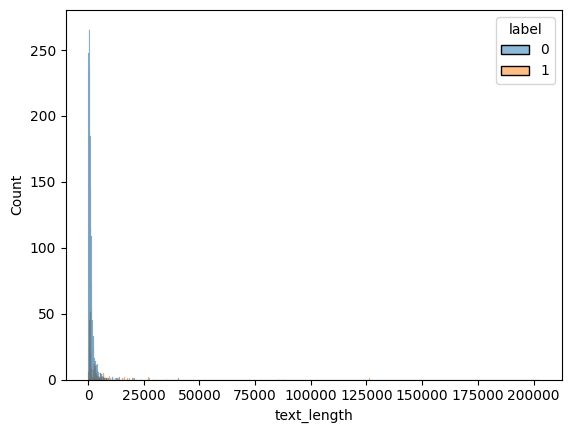

In [ ]:

sns.histplot(data=df, x=df["text_length"], hue=df["label"])
